In [1]:
!git clone https://github.com/jantic/DeOldify.git
%cd DeOldify
!pip install -r requirements-colab.txt

fatal: destination path 'DeOldify' already exists and is not an empty directory.
/content/DeOldify


In [2]:
!mkdir -p /content/DeOldify/models

!wget https://data.deepai.org/deoldify/ColorizeArtistic_gen.pth \
-O /content/DeOldify/models/ColorizeArtistic_gen.pth

--2026-05-07 18:53:41--  https://data.deepai.org/deoldify/ColorizeArtistic_gen.pth
Resolving data.deepai.org (data.deepai.org)... 89.187.162.242, 2400:52e0:1500::1024:1
Connecting to data.deepai.org (data.deepai.org)|89.187.162.242|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 255144681 (243M) [application/octet-stream]
Saving to: ‘/content/DeOldify/models/ColorizeArtistic_gen.pth’

/content/DeOldify/m 100%[===================>] 243.32M  4.90MB/s    in 50s     

2026-05-07 18:54:30 (4.91 MB/s) - ‘/content/DeOldify/models/ColorizeArtistic_gen.pth’ saved [255144681/255144681]



In [3]:
import torch

_old_load = torch.load

def patched_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _old_load(*args, **kwargs)

torch.load = patched_load

In [4]:
#NOTE:  This must be the first call in order to work properly!
from deoldify import device
from deoldify.device_id import DeviceId
#choices:  CPU, GPU0...GPU7
device.set(device=DeviceId.GPU0)

<DeviceId.GPU0: 0>

In [5]:
from deoldify.visualize import *
plt.style.use('dark_background')
torch.backends.cudnn.benchmark=True
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*?Your .*? set is empty.*?")

INFO:numexpr.utils:NumExpr defaulting to 2 threads.


NumExpr defaulting to 2 threads.


NOTE:  Set artistic to False if you're having trouble getting a good render.  Chances are it will work with the Stable model.

In [6]:
colorizer = get_image_colorizer(artistic=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can

# Instructions

### source_url
Type in a url to a direct link of an image.  Usually that means they'll end in .png, .jpg, etc.  NOTE: If you want to use your own image, you can set source_url to None and just upload the image to /test_images/ in Jupyter.  Just make sure that the source_path parameter matches the file you uploaded.

### source_path
Name this whatever sensible image path (plus extension of jpg/png/ext) you want!  Sensible means the path exists and the file exists if source_url=None.

### render_factor
The default value of 35 has been carefully chosen and should work -ok- for most scenarios (but probably won't be the -best-). This determines resolution at which the color portion of the image is rendered. Lower resolution will render faster, and colors also tend to look more vibrant. Older and lower quality images in particular will generally benefit by lowering the render factor. Higher render factors are often better for higher quality images, but the colors may get slightly washed out.

### result_path
Ditto- don't change.

### How to Download a Copy
Simply shift+right click on the displayed image and click "Save Image As..."!


## Pro Tips
1. You can evaluate how well the image is rendered at each render_factor by using the code at the bottom (that cell under "See how well render_factor values perform on a frame here").
2. Keep in mind again that you can go up top and set artistic to False for the colorizer to use the 'Stable' model instead.  This will often tend to do better on portraits, and natural landscapes.  


## Troubleshooting
If you get a 'CUDA out of memory' error, you probably have the render_factor too high.  The max is 45 on 11GB video cards.

## Colorize!!

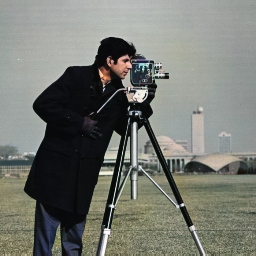

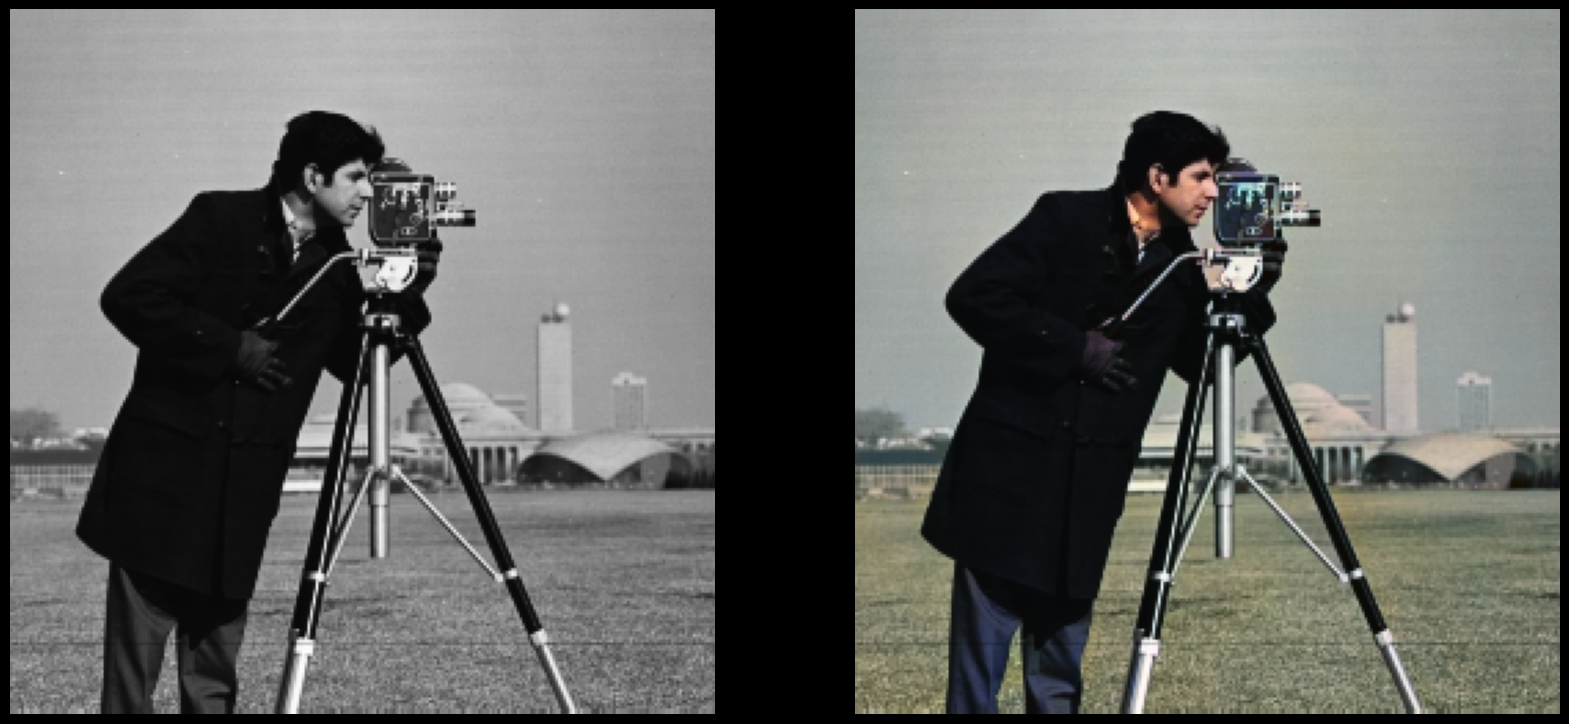

In [13]:
# NOTE: 35 is usually the best quality/speed balance
render_factor = 35

# Your uploaded image path
source_path = '/content/sample_data/test_ip3.png'

# Colorize image
result_path = colorizer.plot_transformed_image(
    path=source_path,
    render_factor=render_factor,
    compare=True,
    watermarked=False
)

# Show result
show_image_in_notebook(result_path)

## See how well render_factor values perform on the image here

In [ ]:
#for i in range(10,46):
    #colorizer.plot_transformed_image(source_path, render_factor=i, display_render_factor=True, figsize=(10,10))